# BTPR3203 — Bullying Analysis Project

In [82]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Image

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    r2_score, mean_absolute_error, mean_squared_error, cohen_kappa_score,
)
from statsmodels.miscmodels.ordinal_model import OrderedModel

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Shared locations -----------------------------------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"        
DATA_DIR.mkdir(parents=True, exist_ok=True)



## Part 1 — RQ1: School Bullying Factor Analysis

Pipeline: data loading & cleaning → correlation analysis → ordinal logistic regression (a full-data **inference** model for coefficients/significance, plus a train/test **prediction** model for held-out accuracy) → visualization of findings.
Outputs → `R1_output/`

In [83]:
R1_DATA_PATH = DATA_DIR / "Mental_Records.csv"
R1_OUTPUT_DIR = PROJECT_ROOT / "R1_output"
R1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



In [84]:
# --- 1.2 Data loading & cleaning ---------------------------------------
def resolve_target_column(df: pd.DataFrame) -> str:
    """Set bullying severity as the target variable."""
    target_col = "bullying"

    if target_col not in df.columns:
        raise KeyError(
            f"Target column '{target_col}' was not found in the dataset."
        )

    return target_col


def load_and_clean_data_r1(path: Path) -> tuple[pd.DataFrame, str]:
    """Load the raw CSV and normalize it for modeling."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find '{path}'. Place the cleaned file at '{R1_DATA_PATH}'."
        )

    df = None
    for sep in (";", ","):
        try:
            candidate = pd.read_csv(path, sep=sep, encoding="utf-8-sig")
        except Exception:
            continue
        if not candidate.empty and (len(candidate.columns) > 1 or sep == ","):
            df = candidate
            break

    if df is None:
        raise ValueError(f"Failed to parse '{path}' as a valid CSV file.")
    if df.empty:
        raise ValueError(f"'{path}' was read successfully but contains no rows.")

    df = df.replace(r"^\s*$", pd.NA, regex=True)
    df = df.dropna(axis=1, how="all")

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    rows_before = len(df)
    df = df.dropna()
    rows_after = len(df)
    print(
        f"Loaded {rows_before} rows; dropped {rows_before - rows_after} rows "
        f"with missing values ({rows_after} rows remain)."
    )

    if df.empty:
        raise ValueError("No complete rows remain after cleaning the dataset.")

    target_col = resolve_target_column(df)

    n_classes = df[target_col].nunique()
    if n_classes < 2:
        raise ValueError(f"Target column '{target_col}' has only one class; cannot model it.")

    return df, target_col


df_r1, target_col_r1 = load_and_clean_data_r1(R1_DATA_PATH)
display(df_r1.head())


Loaded 1100 rows; dropped 0 rows with missing values (1100 rows remain).


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


In [85]:
# --- 1.3 Correlation analysis ------------------------------------------
def run_correlation_analysis_r1(df, target_col):
    numeric_df = df.select_dtypes(include="number")
    corr = numeric_df.corr(method="pearson")

    print("\nCorrelation Matrix")
    print(corr.round(3))

    print("\nTarget distribution")
    print(df[target_col].value_counts().sort_index())
    print(df[target_col].value_counts(normalize=True).sort_index().round(3))

    if target_col in corr.columns:
        target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
        print(f"\nCorrelation with {target_col}")
        print(target_corr.round(3))

    return corr


corr_r1 = run_correlation_analysis_r1(df_r1, target_col_r1)



Correlation Matrix
                              anxiety_level  self_esteem  \
anxiety_level                         1.000       -0.673   
self_esteem                          -0.673        1.000   
mental_health_history                 0.634       -0.604   
depression                            0.694       -0.700   
headache                              0.633       -0.626   
blood_pressure                        0.331       -0.515   
sleep_quality                        -0.710        0.663   
breathing_problem                     0.562       -0.511   
noise_level                           0.609       -0.571   
living_conditions                    -0.568        0.551   
safety                               -0.651        0.644   
basic_needs                          -0.637        0.631   
academic_performance                 -0.650        0.639   
study_load                            0.586       -0.575   
teacher_student_relationship         -0.663        0.653   
future_career_concer

In [86]:
# --- 1.4 Ordinal logistic regression -------------------------------------
def run_ordinal_regression_r1(df, target_col):
    """
    Two models are fit here, for two different purposes:

    1) A model on the FULL dataset, used purely for INFERENCE - i.e. to read
       off coefficients, p-values, and pseudo R^2 and answer "which factors
       are statistically associated with the outcome, and how well does the
       model fit overall?"

    2) A model fit on a TRAINING split only, then evaluated on a held-out
       TEST split, used purely for PREDICTION PERFORMANCE - i.e. to answer
       "if I only had this model, how well could it actually predict the
       outcome for students it hasn't seen?"

    These answer different questions and should not be conflated: a model
    can have statistically significant coefficients and still predict new
    cases poorly (this is common with weak/noisy behavioral predictors).
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    class_labels = np.sort(y.unique())
    n_thresholds = len(class_labels) - 1

    # --- Inference model (full data) ---------------------------------
    full_model = OrderedModel(y, X, distr="logit")
    full_result = full_model.fit(method="bfgs", disp=False)

    # The last n_thresholds parameters are the cut points between ordinal
    # categories, not feature coefficients - exclude them from the
    # "influential factors" ranking.
    coef = full_result.params.iloc[:-n_thresholds]
    pvalues = full_result.pvalues.iloc[:-n_thresholds]
    std_err = full_result.bse.iloc[:-n_thresholds]
    ci = full_result.conf_int(alpha=0.05).iloc[:-n_thresholds]
    ci.columns = ["ci_lower", "ci_upper"]

    inference_table_r1 = pd.DataFrame({
        "coefficient": coef,
        "std_err": std_err,
        "ci_lower": ci["ci_lower"],
        "ci_upper": ci["ci_upper"],
        "p_value": pvalues,
        "significant_at_0.05": pvalues < 0.05,
    }).reindex(coef.abs().sort_values(ascending=False).index)
    # A 95% CI that does not cross zero agrees with p < 0.05 - both are
    # shown so you can report either "the CI excludes zero" or "p < 0.05"
    # phrasing, whichever your write-up calls for.

    print(full_result.summary())
    print(f"\nPseudo R-squared (McFadden): {full_result.prsquared:.4f}")
    print("(This is NOT directly comparable to OLS R^2 - it measures "
          "improvement in log-likelihood over an intercept-only model, "
          "not variance explained.)")
    print("\nMost influential factors (full-data model, ranked by |coefficient|,")
    print("with 95% confidence intervals):")
    print(inference_table_r1.round(4))

    # --- Prediction model (train/test split) --------------------------
    X_train_r1, X_test_r1, y_train_r1, y_test_r1 = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    train_model_r1 = OrderedModel(y_train_r1, X_train_r1, distr="logit")
    train_result_r1 = train_model_r1.fit(method="bfgs", disp=False)

    pred_probs_r1 = train_result_r1.model.predict(train_result_r1.params, exog=X_test_r1)
    y_pred_r1 = class_labels[np.argmax(pred_probs_r1, axis=1)]

    accuracy_r1 = accuracy_score(y_test_r1, y_pred_r1)
    mae_r1 = mean_absolute_error(y_test_r1, y_pred_r1)
    # Linear-weighted kappa penalizes predictions proportionally to how far
    # off they are on the ordinal scale (e.g. predicting 1 instead of 2 is
    # penalized less than predicting 1 instead of 5).
    kappa_r1 = cohen_kappa_score(y_test_r1, y_pred_r1, weights="linear")
    cm_r1 = confusion_matrix(y_test_r1, y_pred_r1, labels=class_labels)
    report_r1 = classification_report(y_test_r1, y_pred_r1, labels=class_labels, zero_division=0)

    print("\nPrediction Performance (held-out test set, 20% of data)")
    print("-" * 60)
    print(f"Accuracy:                 {accuracy_r1:.3f}")
    print(f"Mean Absolute Error:      {mae_r1:.3f}  (average # of categories off)")
    print(f"Weighted Cohen\'s kappa:   {kappa_r1:.3f}  (linear weights; agreement above chance)")
    print("\nClassification report:")
    print(report_r1)
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(pd.DataFrame(cm_r1, index=class_labels, columns=class_labels))

    return {
        "coefficients": coef.reindex(inference_table_r1.index),
        "ci_lower": inference_table_r1["ci_lower"],
        "ci_upper": inference_table_r1["ci_upper"],
        "inference_table": inference_table_r1,
        "pseudo_r2": full_result.prsquared,
        "confusion_matrix": cm_r1,
        "class_labels": class_labels,
        "accuracy": accuracy_r1,
        "mae": mae_r1,
        "kappa": kappa_r1,
    }


reg_results_r1 = run_ordinal_regression_r1(df_r1, target_col_r1)


                             OrderedModel Results                             
Dep. Variable:               bullying   Log-Likelihood:                -1201.1
Model:                   OrderedModel   AIC:                             2452.
Method:            Maximum Likelihood   BIC:                             2577.
Date:                Thu, 20 Aug 2026                                         
Time:                        09:26:05                                         
No. Observations:                1100                                         
Df Residuals:                    1075                                         
Df Model:                          20                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
anxiety_level                    0.0555      0.020      2.735      0.006       0.016       0.09

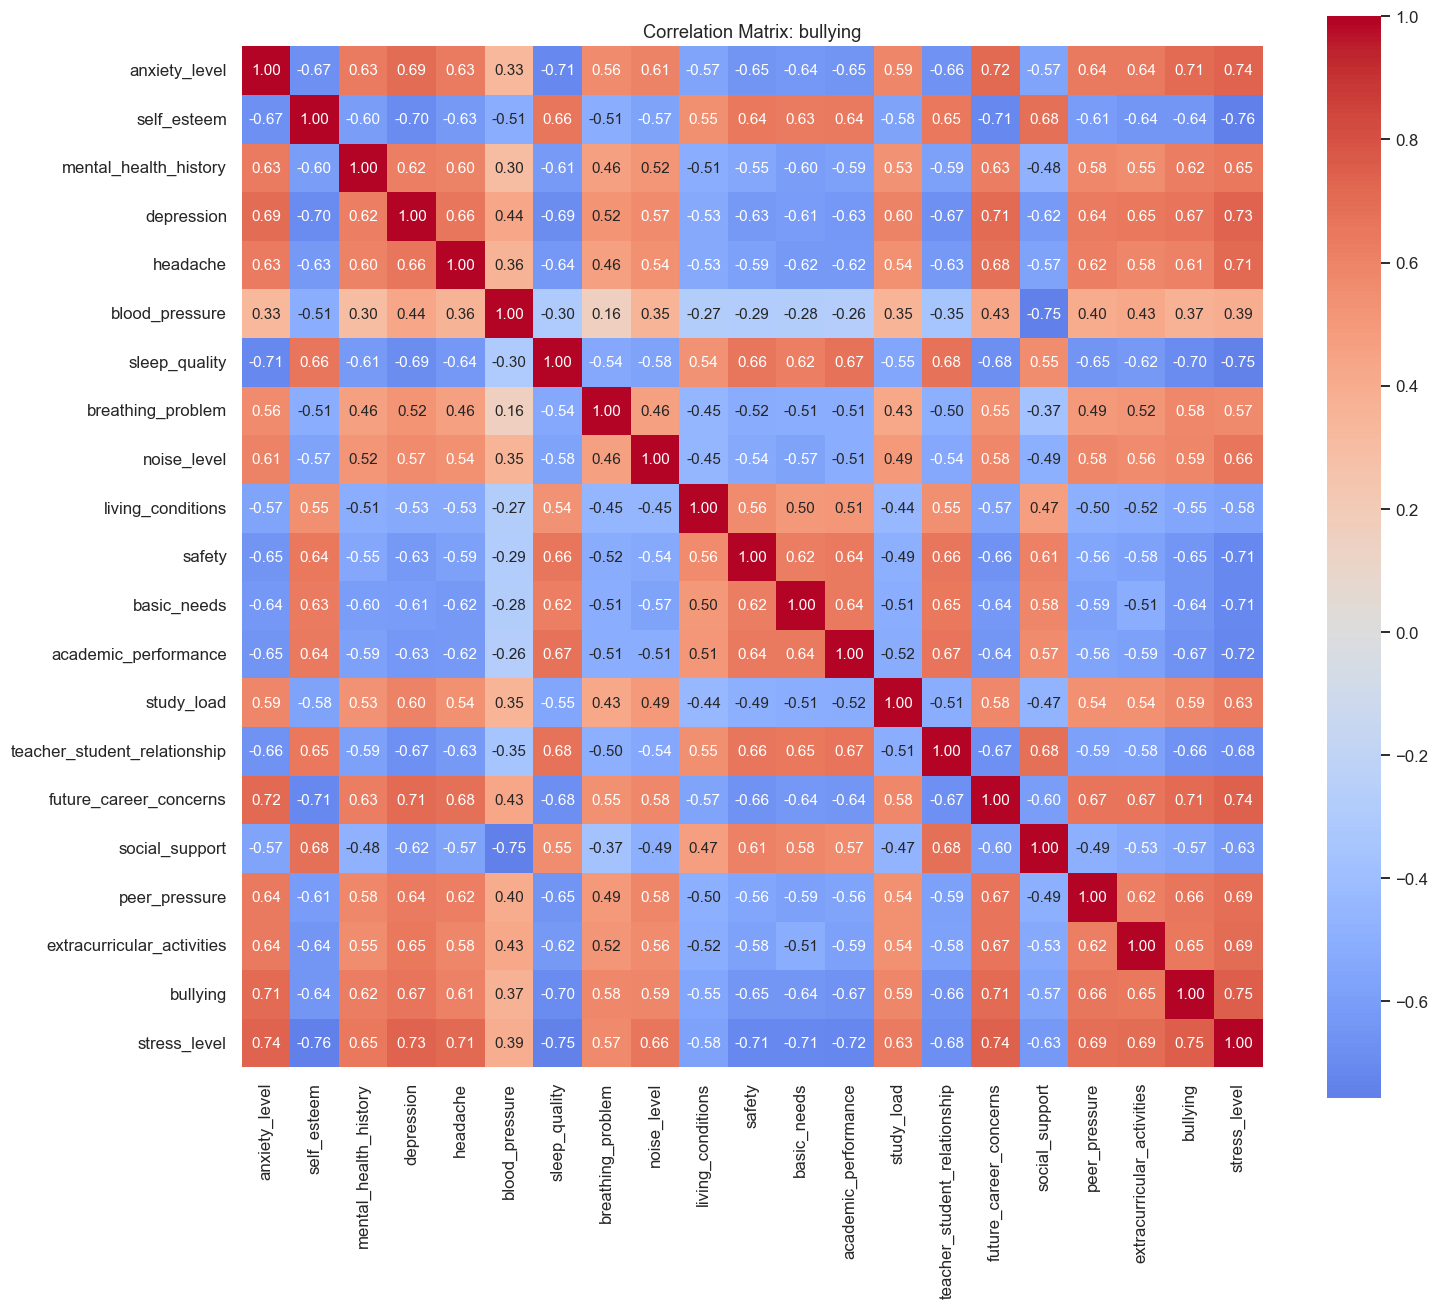


Saved correlation heatmap to 'c:\Users\blank\Document\Python\Python_For_Computer_Science_Project\R1_output\R1_correlation_heatmap.png'


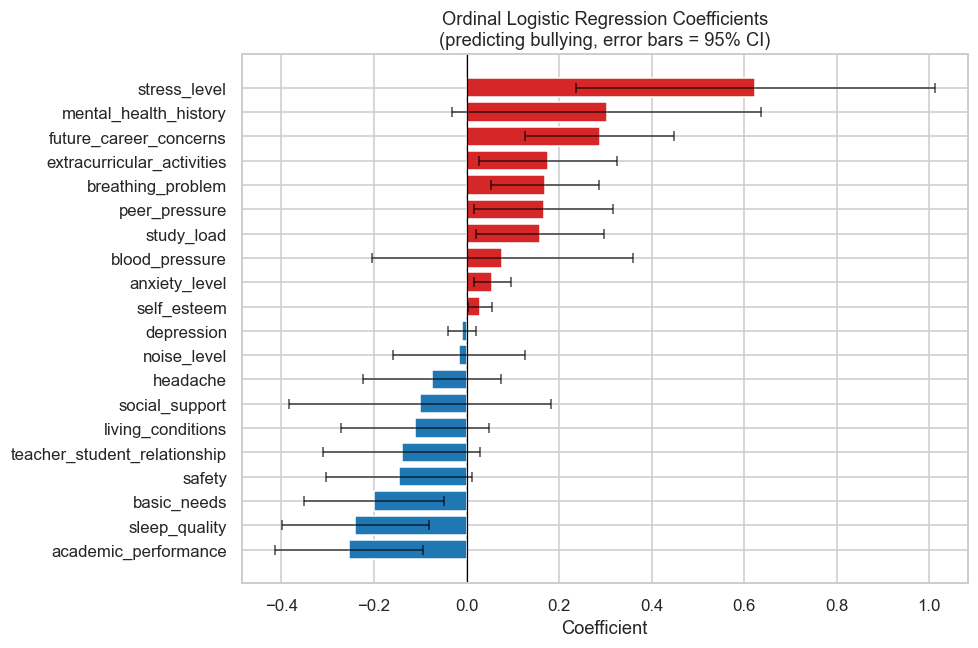

Saved regression coefficient chart to 'c:\Users\blank\Document\Python\Python_For_Computer_Science_Project\R1_output\R1_regression_coefficients.png'


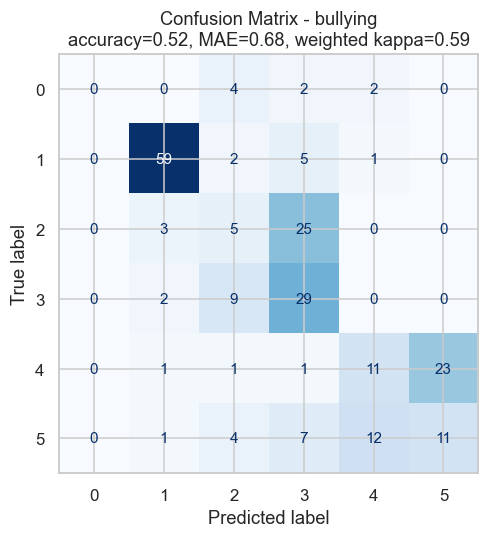

Saved confusion matrix to 'c:\Users\blank\Document\Python\Python_For_Computer_Science_Project\R1_output\R1_confusion_matrix.png'


In [87]:
# --- 1.5 Visualize findings ---------------------------------------------
def visualize_findings_r1(corr: pd.DataFrame, reg_results: dict, output_dir: Path, target_col: str):
    # Correlation heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title(f"Correlation Matrix: {target_col}")
    plt.tight_layout()
    heatmap_path = output_dir / "R1_correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=150)
    plt.show()
    print(f"\nSaved correlation heatmap to '{heatmap_path}'")

    # Feature coefficient bar chart, with 95% CI error bars
    coef_series = reg_results["coefficients"].sort_values()
    ci_lower = reg_results["ci_lower"].reindex(coef_series.index)
    ci_upper = reg_results["ci_upper"].reindex(coef_series.index)
    err_low = coef_series - ci_lower
    err_high = ci_upper - coef_series

    plt.figure(figsize=(9, 6))
    colors = ["#d62728" if v > 0 else "#1f77b4" for v in coef_series.values]
    plt.barh(
        coef_series.index, coef_series.values, color=colors,
        xerr=[err_low.values, err_high.values], capsize=3,
        error_kw={"ecolor": "black", "elinewidth": 1, "alpha": 0.7},
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(
        f"Ordinal Logistic Regression Coefficients\n"
        f"(predicting {target_col}, error bars = 95% CI)"
    )
    plt.xlabel("Coefficient")
    plt.tight_layout()
    coef_path = output_dir / "R1_regression_coefficients.png"
    plt.savefig(coef_path, dpi=150)
    plt.show()
    print(f"Saved regression coefficient chart to '{coef_path}'")

    # Confusion matrix (test-set predictions)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=reg_results["confusion_matrix"],
        display_labels=reg_results["class_labels"],
    )
    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(
        f"Confusion Matrix - {target_col}\n"
        f"accuracy={reg_results['accuracy']:.2f}, MAE={reg_results['mae']:.2f}, "
        f"weighted kappa={reg_results['kappa']:.2f}"
    )
    plt.tight_layout()
    cm_path = output_dir / "R1_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Saved confusion matrix to '{cm_path}'")

    return heatmap_path, coef_path, cm_path


heatmap_path_r1, coef_path_r1, cm_path_r1 = visualize_findings_r1(corr_r1, reg_results_r1, R1_OUTPUT_DIR, target_col_r1)


In [88]:
# --- 1.6 Save cleaned dataset --------------------------------------------
r1_clean_path = R1_OUTPUT_DIR / "bullying_records_cleaned_r1.csv"
df_r1.to_csv(r1_clean_path, index=False)
print(f"\nSaved cleaned dataset to '{r1_clean_path}'")
print("\nRQ1 analysis complete.")
display(df_r1.head())



Saved cleaned dataset to 'c:\Users\blank\Document\Python\Python_For_Computer_Science_Project\R1_output\bullying_records_cleaned_r1.csv'

RQ1 analysis complete.


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


## Part 2 — RQ2: Bullying Severity by Demographics & Well-being

Pipeline: data loading & cleaning → EDA → feature engineering (severity index, demographics, support/loneliness scores) → quantitative tests (chi-square, Kruskal-Wallis, ANOVA, correlation) → save summary outputs → regression ML pipeline predicting loneliness from bullying severity + demographics.

In [89]:
# --- 2.1 Configuration ---------------------------------------------------
R2_DATA_PATH = DATA_DIR / "Bullying_2018.csv"
R2_OUTPUT_DIR = PROJECT_ROOT / "R2_bullyinglevel_demographic"
R2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



In [90]:
# --- 2.2 Data loading & cleaning -----------------------------------------
# The source file is semicolon-delimited, but if it was re-saved/re-exported
# with a different delimiter, a ';' read collapses everything into 1 column.
# Detect that case and retry with a comma before proceeding.
df_raw_r2 = pd.read_csv(R2_DATA_PATH, sep=";", encoding="utf-8-sig")
if df_raw_r2.shape[1] == 1:
    df_raw_r2 = pd.read_csv(R2_DATA_PATH, sep=",", encoding="utf-8-sig")
print("Raw shape:", df_raw_r2.shape)
assert df_raw_r2.shape[1] > 1, "CSV did not parse into multiple columns with ';' or ',' -- check the file."

df_r2 = df_raw_r2.copy()

# Normalise all string columns: strip whitespace, turn blank strings into NaN
for c in df_r2.columns:
    if df_r2[c].dtype == object or str(df_r2[c].dtype) in ("str", "string"):
        df_r2[c] = df_r2[c].astype(str).str.strip()
        df_r2[c] = df_r2[c].replace({"": np.nan, "nan": np.nan})

# 'record' is a row identifier, not an analytical feature -> set as index
df_r2 = df_r2.set_index("record")
print("Cleaned shape:", df_r2.shape)
df_r2.head()


Raw shape: (56981, 18)
Cleaned shape: (56981, 17)


,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
record,,,,,,,,,,,,,,,,,
1,Yes,Yes,NaN,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,NaN,NaN,NaN
2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,NaN,NaN,NaN
3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,NaN,No,No,No,No,No
5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,NaN,NaN,NaN


### 2.3 Exploratory Data Analysis (EDA)

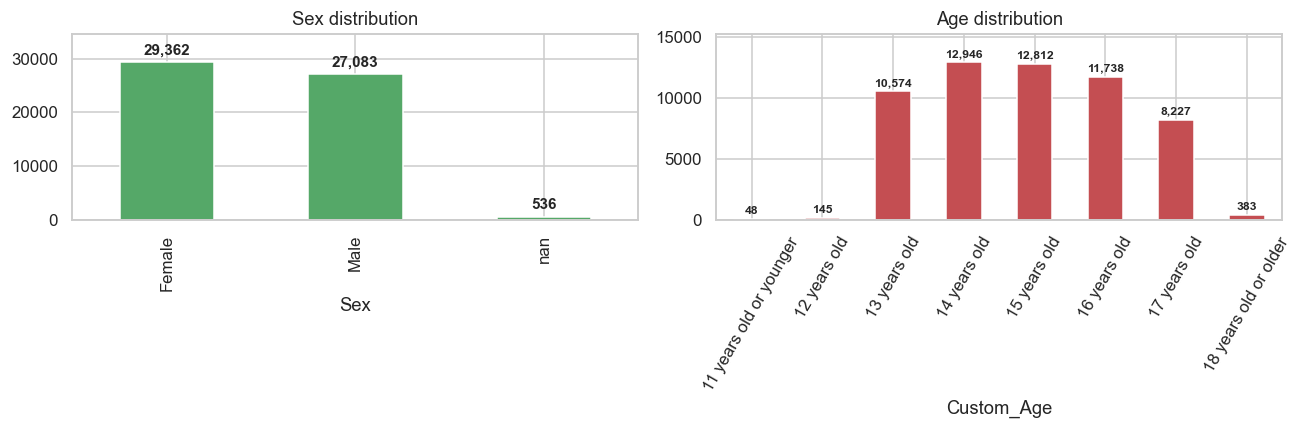

In [91]:
fig_r2, axes_r2 = plt.subplots(1, 2, figsize=(12, 4))
df_r2["Sex"].value_counts(dropna=False).plot(kind="bar", ax=axes_r2[0], color="#55A868")
axes_r2[0].set_title("Sex distribution")
for container in axes_r2[0].containers:
    axes_r2[0].bar_label(container, fmt="{:,.0f}", padding=3, fontsize=10, fontweight="bold")

age_order_r2 = ["11 years old or younger", "12 years old", "13 years old", "14 years old",
                "15 years old", "16 years old", "17 years old", "18 years old or older"]
df_r2["Custom_Age"].value_counts().reindex(age_order_r2).plot(kind="bar", ax=axes_r2[1], color="#C44E52")
axes_r2[1].set_title("Age distribution")
axes_r2[1].tick_params(axis="x", rotation=60)
for container in axes_r2[1].containers:
    axes_r2[1].bar_label(container, fmt="{:,.0f}", padding=2, fontsize=8, fontweight="bold")
for ax in axes_r2:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "eda_demographics.png", bbox_inches="tight")
plt.show()


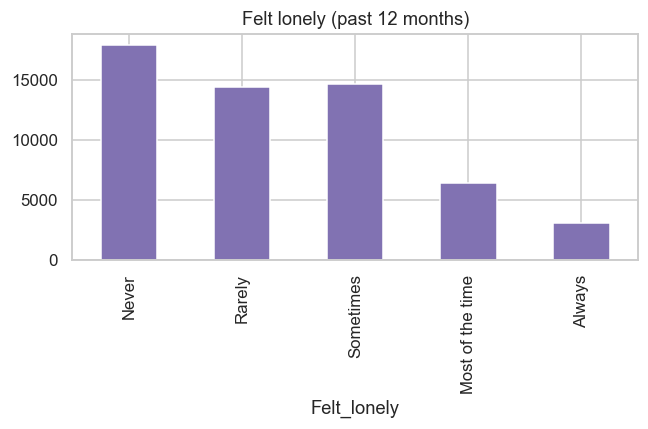

In [92]:
fig2b_r2, ax2b_r2 = plt.subplots(figsize=(6, 4))
lonely_order_r2 = ["Never", "Rarely", "Sometimes", "Most of the time", "Always"]
df_r2["Felt_lonely"].value_counts().reindex(lonely_order_r2).plot(kind="bar", ax=ax2b_r2, color="#8172B2")
ax2b_r2.set_title("Felt lonely (past 12 months)")
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "eda_loneliness_dist.png", bbox_inches="tight")
plt.show()


### 2.4 Feature Engineering

In [93]:
# --- Bullying_Severity_Index & Bullying_Pattern ---
bully_cols_r2 = ["Bullied_on_school_property_in_past_12_months",
                 "Bullied_not_on_school_property_in_past_12_months",
                 "Cyber_bullied_in_past_12_months"]

complete_bully_r2 = df_r2[bully_cols_r2].notna().all(axis=1)
df_r2["Bullying_Severity_Index"] = np.nan
df_r2.loc[complete_bully_r2, "Bullying_Severity_Index"] = (
    df_r2.loc[complete_bully_r2, bully_cols_r2] == "Yes"
).sum(axis=1)

pattern_map_r2 = {0: "Not bullied", 1: "Single-form", 2: "Dual-form", 3: "Poly-bullied (all 3 forms)"}
df_r2["Bullying_Pattern"] = df_r2["Bullying_Severity_Index"].map(pattern_map_r2)
df_r2["Bullying_Pattern"] = pd.Categorical(
    df_r2["Bullying_Pattern"],
    categories=["Not bullied", "Single-form", "Dual-form", "Poly-bullied (all 3 forms)"],
    ordered=True,
)

df_r2["Bullied_Any"] = np.where(
    df_r2["Bullying_Severity_Index"].isna(), np.nan,
    (df_r2["Bullying_Severity_Index"] > 0).astype(float),
)

print(df_r2["Bullying_Pattern"].value_counts())


Bullying_Pattern
Not bullied                   33092
Single-form                   12390
Dual-form                      6190
Poly-bullied (all 3 forms)     3564
Name: count, dtype: int64


In [94]:
# --- Age_Group (collapsed, ordered demographic subgroup) ---
age_group_map_r2 = {
    "11 years old or younger": "<=13", "12 years old": "<=13", "13 years old": "<=13",
    "14 years old": "14-15", "15 years old": "14-15",
    "16 years old": "16-17", "17 years old": "16-17",
    "18 years old or older": "18+",
}
df_r2["Age_Group"] = df_r2["Custom_Age"].map(age_group_map_r2)
df_r2["Age_Group"] = pd.Categorical(df_r2["Age_Group"], categories=["<=13", "14-15", "16-17", "18+"], ordered=True)
df_r2["Age_Group"].value_counts().sort_index()


Age_Group
<=13     10767
14-15    25758
16-17    19965
18+        383
Name: count, dtype: int64

In [95]:
# --- Loneliness_Score, support sub-scores, composite Social_Support_Index, Missed_Days_Approx ---
lonely_scale_r2 = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Most of the time": 3, "Always": 4}
df_r2["Loneliness_Score"] = df_r2["Felt_lonely"].map(lonely_scale_r2)

support_scale_r2 = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Most of the time": 3, "Always": 4}
df_r2["Peer_Support_Score"] = df_r2["Other_students_kind_and_helpful"].map(support_scale_r2)
df_r2["Parental_Support_Score"] = df_r2["Parents_understand_problems"].map(support_scale_r2)
friends_scale_r2 = {"0": 0, "1": 1, "2": 2, "3 or more": 3}
df_r2["Close_Friends_Score"] = df_r2["Close_friends"].map(friends_scale_r2)

support_components_r2 = ["Peer_Support_Score", "Parental_Support_Score", "Close_Friends_Score"]
z_r2 = df_r2[support_components_r2].apply(lambda s: (s - s.mean()) / s.std())
df_r2["Social_Support_Index"] = z_r2.mean(axis=1)

days_scale_r2 = {"0 days": 0, "1 or 2 days": 1.5, "3 to 5 days": 4, "6 to 9 days": 7.5, "10 or more days": 12}
df_r2["Missed_Days_Approx"] = df_r2["Miss_school_no_permission"].map(days_scale_r2)

df_r2[["Bullying_Severity_Index", "Age_Group", "Loneliness_Score", "Social_Support_Index", "Missed_Days_Approx"]].describe(include="all")


,Bullying_Severity_Index,Age_Group,Loneliness_Score,Social_Support_Index,Missed_Days_Approx
count,55236.000000,56873,56615.000000,56870.000000,55117.00000
unique,NaN,4,NaN,NaN,NaN
top,NaN,14-15,NaN,NaN,NaN
freq,NaN,25758,NaN,NaN,NaN
mean,0.642009,NaN,1.335423,-0.002665,1.05062
std,0.917124,NaN,1.189118,0.691531,2.37212
min,0.000000,NaN,0.000000,-2.824245,0.00000
25%,0.000000,NaN,0.000000,-0.437146,0.00000
50%,0.000000,NaN,1.000000,0.063184,0.00000
75%,1.000000,NaN,2.000000,0.563946,1.50000


### 2.5 Quantitative Analysis

#### Analysis 1 — Prevalence & overlap of the three bullying types (descriptive)

In [96]:
complete_r2 = df_r2[bully_cols_r2].notna().all(axis=1)
n_complete_r2 = complete_r2.sum()
print(f"Students with complete data on all 3 bullying items: {n_complete_r2} ({n_complete_r2/len(df_r2)*100:.1f}% of sample)")

severity_counts_r2 = df_r2["Bullying_Pattern"].value_counts().reindex(
    ["Not bullied", "Single-form", "Dual-form", "Poly-bullied (all 3 forms)"])
severity_pct_r2 = (severity_counts_r2 / severity_counts_r2.sum() * 100).round(1)
pd.DataFrame({"n": severity_counts_r2, "%": severity_pct_r2})


Students with complete data on all 3 bullying items: 55236 (96.9% of sample)


,n,%
Bullying_Pattern,,
Not bullied,33092,59.9
Single-form,12390,22.4
Dual-form,6190,11.2
Poly-bullied (all 3 forms),3564,6.5


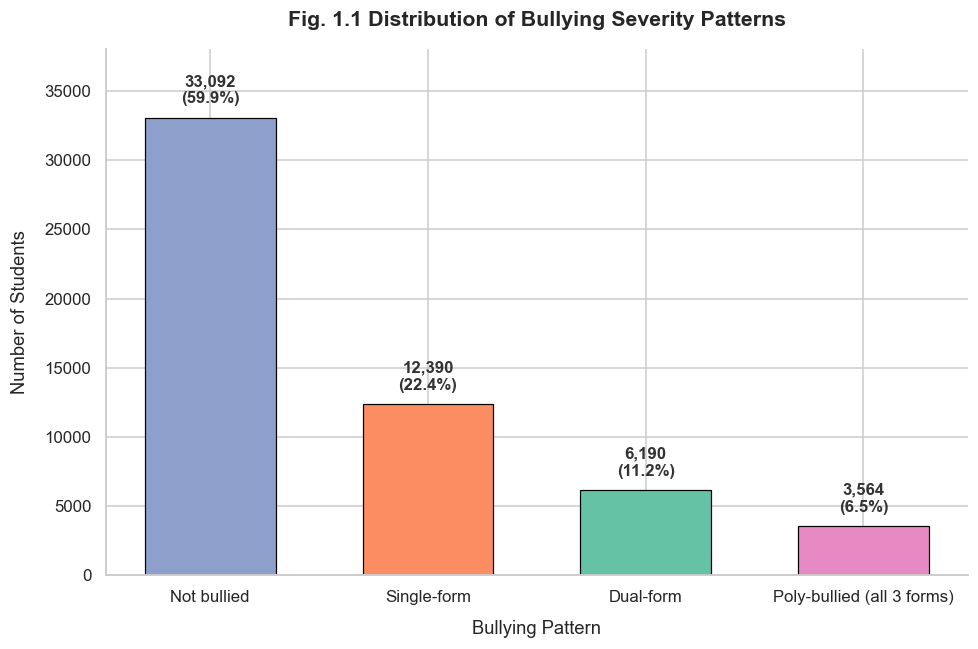

In [97]:
fig1_r2, ax1_r2 = plt.subplots(figsize=(9, 6))

patterns_r2 = severity_counts_r2.index
counts_r2 = severity_counts_r2.values
pcts_r2 = severity_pct_r2.values
colors_r2 = ["#8DA0CB", "#FC8D62", "#66C2A5", "#E78AC3"]

ax1_r2.bar(patterns_r2, counts_r2, color=colors_r2, edgecolor="black", linewidth=0.8, width=0.6)
ax1_r2.set_title("Fig. 1.1 Distribution of Bullying Severity Patterns", fontsize=14, fontweight="bold", pad=15)
ax1_r2.set_xlabel("Bullying Pattern", fontsize=12, labelpad=10)
ax1_r2.set_ylabel("Number of Students", fontsize=12, labelpad=10)

for i, (count, pct) in enumerate(zip(counts_r2, pcts_r2)):
    ax1_r2.text(i, count + 800, f"{count:,}\n({pct}%)", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#333333")

ax1_r2.set_ylim(0, max(counts_r2) * 1.15)
ax1_r2.spines["top"].set_visible(False)
ax1_r2.spines["right"].set_visible(False)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig1.1_bullying_severity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


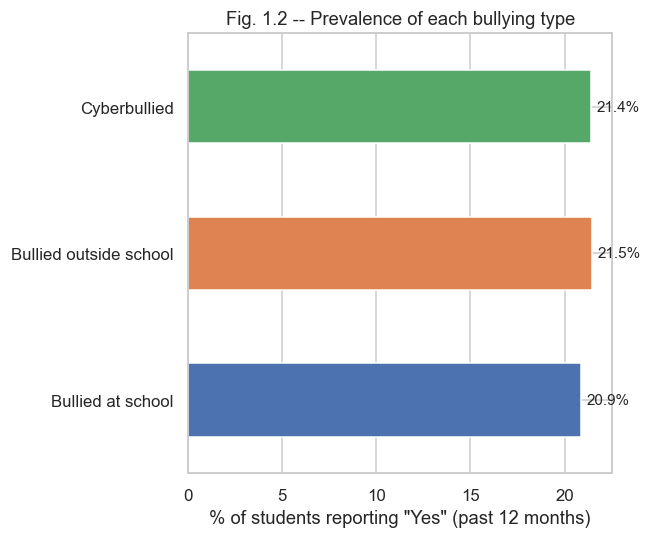

In [98]:
fig1b_r2, ax1b_r2 = plt.subplots(figsize=(6, 5))
prevalence_r2 = pd.Series({
    "Bullied at school": (df_r2["Bullied_on_school_property_in_past_12_months"] == "Yes").mean() * 100,
    "Bullied outside school": (df_r2["Bullied_not_on_school_property_in_past_12_months"] == "Yes").mean() * 100,
    "Cyberbullied": (df_r2["Cyber_bullied_in_past_12_months"] == "Yes").mean() * 100,
})
prevalence_r2.plot(kind="barh", ax=ax1b_r2, color=["#4C72B0", "#DD8452", "#55A868"])
ax1b_r2.set_xlabel('% of students reporting "Yes" (past 12 months)')
ax1b_r2.set_title("Fig. 1.2 -- Prevalence of each bullying type")
for i, v in enumerate(prevalence_r2.values):
    ax1b_r2.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig1.2_type_prevalence.png", bbox_inches="tight")
plt.show()


#### Analysis 2 — Bullying_Pattern x Sex (chi-square test of independence)

In [99]:
def cramers_v_r2(chi2, n, r, c):
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))


ct_sex_r2 = pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Sex"])
chi2_r2, p_r2, dof_r2, expected_r2 = stats.chi2_contingency(ct_sex_r2)
v_r2 = cramers_v_r2(chi2_r2, ct_sex_r2.values.sum(), *ct_sex_r2.shape)
print(f"Chi-square = {chi2_r2:.2f}, df = {dof_r2}, p = {p_r2:.4g}, Cramer's V = {v_r2:.3f}")
pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Sex"], normalize="columns").mul(100).round(1)


Chi-square = 684.87, df = 3, p = 4.01e-148, Cramer's V = 0.112


Sex,Female,Male
Bullying_Pattern,,
Not bullied,55.2,65.2
Single-form,23.8,20.9
Dual-form,13.1,9.1
Poly-bullied (all 3 forms),7.9,4.8


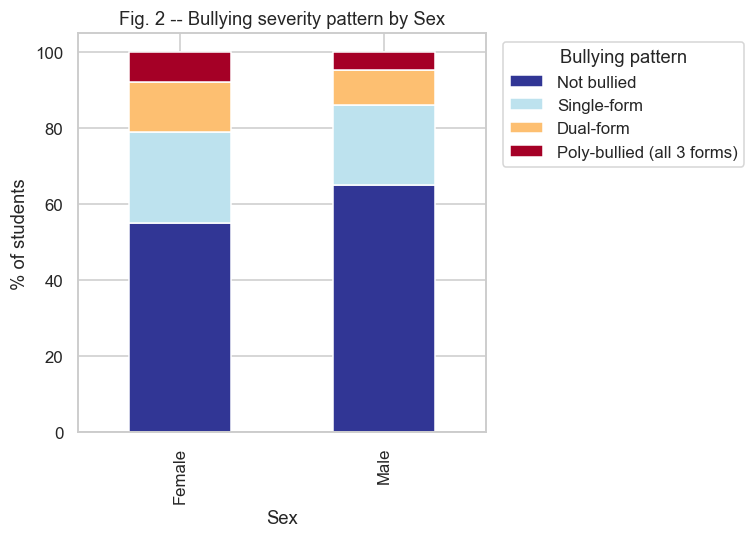

In [100]:
fig2_r2, ax2_r2 = plt.subplots(figsize=(7, 5))
plot_data_r2 = pd.crosstab(df_r2["Sex"], df_r2["Bullying_Pattern"], normalize="index").mul(100)
plot_data_r2 = plot_data_r2[["Not bullied", "Single-form", "Dual-form", "Poly-bullied (all 3 forms)"]]
plot_data_r2.plot(kind="bar", stacked=True, ax=ax2_r2, colormap="RdYlBu_r")
ax2_r2.set_ylabel("% of students")
ax2_r2.set_title("Fig. 2 -- Bullying severity pattern by Sex")
ax2_r2.legend(title="Bullying pattern", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig2_pattern_by_sex.png", bbox_inches="tight")
plt.show()


**Interpretation:** the chi-square test shows a statistically significant association between sex and bullying pattern (p < .001), with a small-to-moderate effect size (Cramer's V ≈ 0.11). Female students report higher rates of dual-form and poly-bullying than male students, with a correspondingly lower "not bullied" rate. This runs counter to the assumption that boys are more exposed to compounding, multi-setting bullying. *Implication:* support resources should not default to treating boys as the primary poly-victimization risk group. *Limitation:* the missing-sex category (~1%) is excluded from this test.

#### Analysis 3 — Bullying_Pattern x Age_Group (chi-square test of independence)

In [101]:
ct_age_r2 = pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Age_Group"])
chi2_r2, p_r2, dof_r2, expected_r2 = stats.chi2_contingency(ct_age_r2)
v_r2 = cramers_v_r2(chi2_r2, ct_age_r2.values.sum(), *ct_age_r2.shape)
print(f"Chi-square = {chi2_r2:.2f}, df = {dof_r2}, p = {p_r2:.4g}, Cramer's V = {v_r2:.3f}")
pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Age_Group"], normalize="columns").mul(100).round(1)


Chi-square = 34.47, df = 9, p = 7.394e-05, Cramer's V = 0.014


Age_Group,<=13,14-15,16-17,18+
Bullying_Pattern,,,,
Not bullied,61.6,59.5,59.5,63.5
Single-form,22.5,22.5,22.3,21.5
Dual-form,10.1,11.4,11.6,10.8
Poly-bullied (all 3 forms),5.8,6.6,6.6,4.1


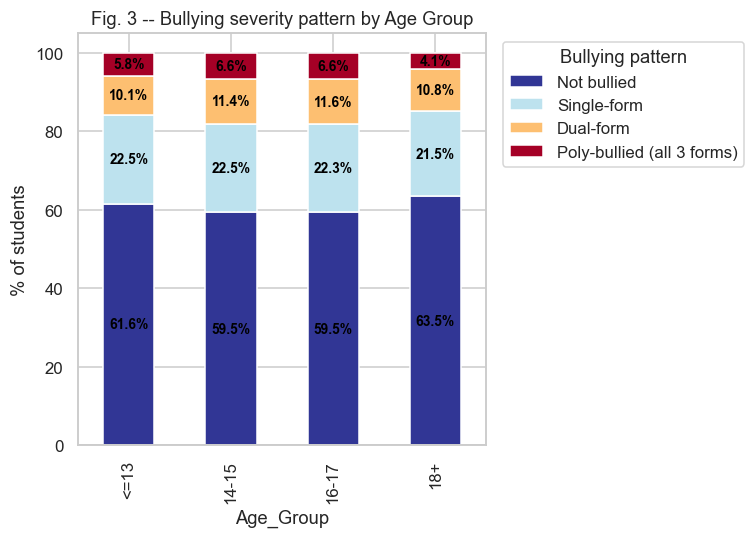

In [102]:
fig3_r2, ax3_r2 = plt.subplots(figsize=(7, 5))
plot_data2_r2 = pd.crosstab(df_r2["Age_Group"], df_r2["Bullying_Pattern"], normalize="index").mul(100)
plot_data2_r2 = plot_data2_r2[["Not bullied", "Single-form", "Dual-form", "Poly-bullied (all 3 forms)"]]
plot_data2_r2.plot(kind="bar", stacked=True, ax=ax3_r2, colormap="RdYlBu_r")

for c in ax3_r2.containers:
    labels = [f"{v:.1f}%" if v >= 4 else "" for v in c.datavalues]
    
    ax3_r2.bar_label(
        c, 
        label_type="center", 
        labels=labels, 
        fontsize=9, 
        fontweight="bold", 
        color="black" 
    )
ax3_r2.set_ylabel("% of students")
ax3_r2.set_title("Fig. 3 -- Bullying severity pattern by Age Group")
ax3_r2.legend(title="Bullying pattern", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig3_pattern_by_age.png", bbox_inches="tight")
plt.show()


#### Analysis 4 — Mental well-being by bullying severity (Kruskal-Wallis)

In [103]:
groups4_r2 = [g["Loneliness_Score"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")]
h_stat4_r2, p_val4_r2 = stats.kruskal(*groups4_r2)
print(f"Kruskal-Wallis H = {h_stat4_r2:.2f}, p = {p_val4_r2:.4g}")

summary4_r2 = df_r2.groupby("Bullying_Severity_Index")["Loneliness_Score"].agg(["mean", "std", "count"]).round(3)
summary4_r2


Kruskal-Wallis H = 4604.40, p = 0


,mean,std,count
Bullying_Severity_Index,,,
0.0,1.069,1.090,32967
1.0,1.568,1.175,12322
2.0,1.907,1.190,6158
3.0,2.021,1.296,3543


#### Analysis 5 — School attendance by bullying severity (Kruskal-Wallis)

In [104]:
groups5_r2 = [g["Missed_Days_Approx"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")]
h_stat5_r2, p_val5_r2 = stats.kruskal(*groups5_r2)
print(f"Kruskal-Wallis H = {h_stat5_r2:.2f}, p = {p_val5_r2:.4g}")

summary5_r2 = df_r2.groupby("Bullying_Severity_Index")["Missed_Days_Approx"].agg(["mean", "std", "count"]).round(3)
summary5_r2


Kruskal-Wallis H = 450.67, p = 2.329e-97


,mean,std,count
Bullying_Severity_Index,,,
0.0,0.892,2.177,32185
1.0,1.158,2.485,11978
2.0,1.323,2.657,5982
3.0,1.434,2.757,3437


#### Analysis 6 — Social support by bullying severity (one-way ANOVA)

In [105]:
groups6_r2 = [g["Social_Support_Index"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")]
f_stat6_r2, p_val6_r2 = stats.f_oneway(*groups6_r2)
print(f"ANOVA F = {f_stat6_r2:.2f}, p = {p_val6_r2:.4g}")

summary6_r2 = df_r2.groupby("Bullying_Severity_Index")["Social_Support_Index"].agg(["mean", "std", "count"]).round(3)
summary6_r2


ANOVA F = 463.58, p = 1.663e-297


,mean,std,count
Bullying_Severity_Index,,,
0.0,0.087,0.675,33048
1.0,-0.065,0.676,12373
2.0,-0.161,0.672,6182
3.0,-0.224,0.718,3555


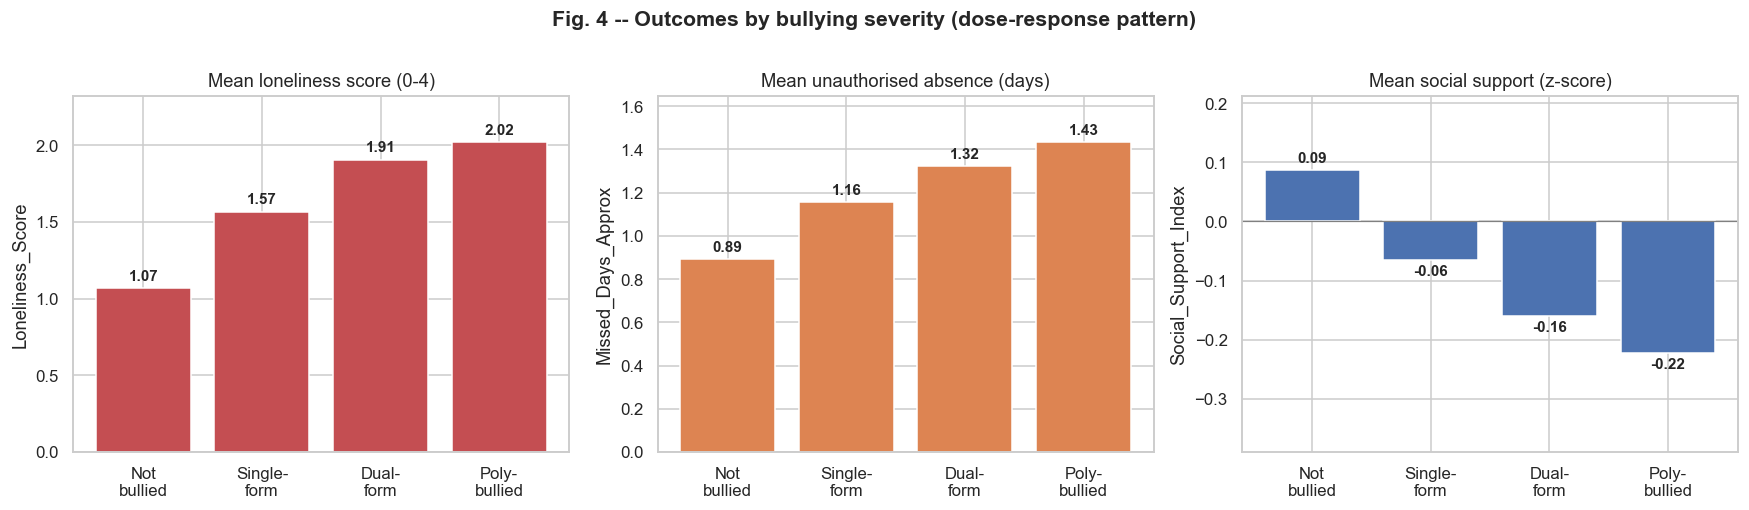

In [106]:
fig4_r2, axes4_r2 = plt.subplots(1, 3, figsize=(16, 4.5))

sev_order_r2 = [0, 1, 2, 3]
sev_labels_r2 = ["Not\nbullied", "Single-\nform", "Dual-\nform", "Poly-\nbullied"]

m1_r2 = df_r2.groupby("Bullying_Severity_Index")["Loneliness_Score"].mean().reindex(sev_order_r2)
bars1 = axes4_r2[0].bar(sev_labels_r2, m1_r2.values, color="#C44E52")
axes4_r2[0].bar_label(bars1, fmt="%.2f", padding=3, fontsize=10, fontweight="bold")
axes4_r2[0].set_title("Mean loneliness score (0-4)")
axes4_r2[0].set_ylabel("Loneliness_Score")
axes4_r2[0].set_ylim(0, m1_r2.max() * 1.15) 

m2_r2 = df_r2.groupby("Bullying_Severity_Index")["Missed_Days_Approx"].mean().reindex(sev_order_r2)
bars2 = axes4_r2[1].bar(sev_labels_r2, m2_r2.values, color="#DD8452")
axes4_r2[1].bar_label(bars2, fmt="%.2f", padding=3, fontsize=10, fontweight="bold")
axes4_r2[1].set_title("Mean unauthorised absence (days)")
axes4_r2[1].set_ylabel("Missed_Days_Approx")
axes4_r2[1].set_ylim(0, m2_r2.max() * 1.15)
m3_r2 = df_r2.groupby("Bullying_Severity_Index")["Social_Support_Index"].mean().reindex(sev_order_r2)
bars3 = axes4_r2[2].bar(sev_labels_r2, m3_r2.values, color="#4C72B0")
axes4_r2[2].bar_label(bars3, fmt="%.2f", padding=3, fontsize=10, fontweight="bold")
axes4_r2[2].set_title("Mean social support (z-score)")
axes4_r2[2].set_ylabel("Social_Support_Index")
axes4_r2[2].axhline(0, color="grey", linewidth=0.8)
y_min, y_max = m3_r2.min(), m3_r2.max()
axes4_r2[2].set_ylim(y_min - abs(y_min)*0.3 - 0.1, y_max + abs(y_max)*0.3 + 0.1)

plt.suptitle("Fig. 4 -- Outcomes by bullying severity (dose-response pattern)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig4_outcomes_by_severity.png", bbox_inches="tight")
plt.show()

#### Analysis 7 — Correlation matrix among severity and outcomes

In [107]:
corr_vars_r2 = ["Bullying_Severity_Index", "Loneliness_Score", "Social_Support_Index", "Missed_Days_Approx"]
corr_matrix_r2 = df_r2[corr_vars_r2].corr(method="spearman")
corr_matrix_r2.round(3)


,Bullying_Severity_Index,Loneliness_Score,Social_Support_Index,Missed_Days_Approx
Bullying_Severity_Index,1.000,0.288,-0.158,0.092
Loneliness_Score,0.288,1.000,-0.293,0.074
Social_Support_Index,-0.158,-0.293,1.000,-0.103
Missed_Days_Approx,0.092,0.074,-0.103,1.000


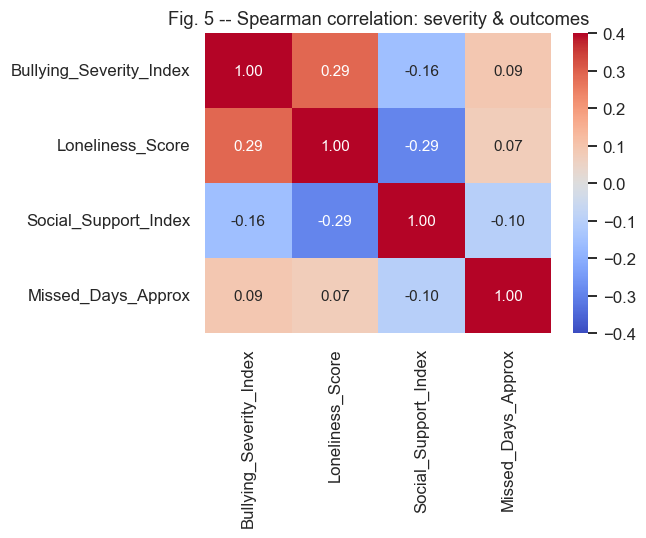

In [108]:
fig5_r2, ax5_r2 = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix_r2, annot=True, cmap="coolwarm", center=0, vmin=-0.4, vmax=0.4, ax=ax5_r2, fmt=".2f")
ax5_r2.set_title("Fig. 5 -- Spearman correlation: severity & outcomes")
plt.tight_layout()
plt.savefig(R2_OUTPUT_DIR / "fig5_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [109]:
summary_table_r2 = (
    df_r2.dropna(subset=["Bullying_Severity_Index"])
      .groupby(["Bullying_Severity_Index", "Sex", "Age_Group"], observed=True)
      .agg(
          n_students=("Bullying_Severity_Index", "size"),
          mean_loneliness=("Loneliness_Score", "mean"),
          mean_missed_days=("Missed_Days_Approx", "mean"),
          mean_social_support=("Social_Support_Index", "mean"),
      )
      .round(3)
      .reset_index()
)
summary_table_r2.to_csv(R2_OUTPUT_DIR / "bullying_severity_outcomes_summary.csv", index=False)
print(f"Saved bullying_severity_outcomes_summary.csv -- {len(summary_table_r2)} rows")


Saved bullying_severity_outcomes_summary.csv -- 32 rows


In [110]:
stats_summary_r2 = {}

ct_sex_stats_r2 = pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Sex"])
c2_r2, p_stat_r2, dof_stat_r2, _ = stats.chi2_contingency(ct_sex_stats_r2)
stats_summary_r2["bullying_pattern_by_sex"] = {
    "chi2": round(c2_r2, 2), "p": p_stat_r2, "dof": int(dof_stat_r2),
    "cramers_v": round(cramers_v_r2(c2_r2, ct_sex_stats_r2.values.sum(), *ct_sex_stats_r2.shape), 3),
}

ct_age_stats_r2 = pd.crosstab(df_r2["Bullying_Pattern"], df_r2["Age_Group"])
c2_r2, p_stat_r2, dof_stat_r2, _ = stats.chi2_contingency(ct_age_stats_r2)
stats_summary_r2["bullying_pattern_by_age_group"] = {
    "chi2": round(c2_r2, 2), "p": p_stat_r2, "dof": int(dof_stat_r2),
    "cramers_v": round(cramers_v_r2(c2_r2, ct_age_stats_r2.values.sum(), *ct_age_stats_r2.shape), 3),
}

h_json_r2, p_json_r2 = stats.kruskal(*[g["Loneliness_Score"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")])
stats_summary_r2["loneliness_by_severity_kruskal"] = {"H": round(h_json_r2, 2), "p": p_json_r2}

h_json_r2, p_json_r2 = stats.kruskal(*[g["Missed_Days_Approx"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")])
stats_summary_r2["missed_days_by_severity_kruskal"] = {"H": round(h_json_r2, 2), "p": p_json_r2}

f_json_r2, p_json_r2 = stats.f_oneway(*[g["Social_Support_Index"].dropna() for _, g in df_r2.groupby("Bullying_Severity_Index")])
stats_summary_r2["social_support_by_severity_anova"] = {"F": round(f_json_r2, 2), "p": p_json_r2}

with open(R2_OUTPUT_DIR / "bullying_severity_test_statistics.json", "w") as f:
    json.dump(stats_summary_r2, f, indent=2)

print("Saved bullying_severity_test_statistics.json")


Saved bullying_severity_test_statistics.json


### 2.7 ML Pipeline — Predicting Loneliness

In [111]:
numeric_features_r2 = ["Bullying_Severity_Index", "Social_Support_Index", "Missed_Days_Approx"]
categorical_features_r2 = ["Sex", "Age_Group"]
target_r2 = "Loneliness_Score"

ml_df_r2 = df_r2[numeric_features_r2 + categorical_features_r2 + [target_r2]].dropna()
print(f"ML-ready rows: {len(ml_df_r2)} ({len(ml_df_r2)/len(df_r2)*100:.1f}% of full sample)")

X_r2 = ml_df_r2[numeric_features_r2 + categorical_features_r2]
y_r2 = ml_df_r2[target_r2]

preprocessor_r2 = ColumnTransformer([
    ("num", StandardScaler(), numeric_features_r2),
    ("cat", OneHotEncoder(drop="first"), categorical_features_r2),
])

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(X_r2, y_r2, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train_r2)}  Test: {len(X_test_r2)}")
print(f"Target range: {y_r2.min()} - {y_r2.max()}  |  Mean: {y_r2.mean():.2f}")


ML-ready rows: 52885 (92.8% of full sample)
Train: 42308  Test: 10577
Target range: 0.0 - 4.0  |  Mean: 1.34


In [112]:
# -- Model A: Plain Linear Regression --
lr_pipeline_r2 = Pipeline([("preprocessor", preprocessor_r2), ("model", LinearRegression())])
lr_pipeline_r2.fit(X_train_r2, y_train_r2)
print("Linear Regression trained.")

# -- Model B: Ridge Regression (L2 regularisation) --
ridge_pipeline_r2 = Pipeline([("preprocessor", preprocessor_r2), ("model", Ridge(alpha=1.0))])
ridge_pipeline_r2.fit(X_train_r2, y_train_r2)
print("Ridge Regression trained.")

# -- Quick manual prediction --
sample_r2 = pd.DataFrame([{
    "Bullying_Severity_Index": 3, "Social_Support_Index": -1.0, "Missed_Days_Approx": 7.5,
    "Sex": "Female", "Age_Group": "16-17",
}])
lr_pred_r2 = lr_pipeline_r2.predict(sample_r2)[0]
ridge_pred_r2 = ridge_pipeline_r2.predict(sample_r2)[0]
print(f"Poly-bullied, low-support student -- LR predicted: {lr_pred_r2:.3f}")
print(f"Poly-bullied, low-support student -- Ridge predicted: {ridge_pred_r2:.3f}")


Linear Regression trained.
Ridge Regression trained.
Poly-bullied, low-support student -- LR predicted: 2.935
Poly-bullied, low-support student -- Ridge predicted: 2.935


In [113]:
def evaluate_r2(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n=== {name} ===")
    print(f"R2 (variance explained)   : {r2:.4f}")
    print(f"MAE (avg error in score)  : {mae:.4f}")
    print(f"RMSE (penalises big miss) : {rmse:.4f}")
    return r2, mae, rmse


evaluate_r2("Linear Regression", lr_pipeline_r2, X_test_r2, y_test_r2)
evaluate_r2("Ridge (alpha=1.0)", ridge_pipeline_r2, X_test_r2, y_test_r2)

for name_r2, pipe_r2 in [("Linear Regression", lr_pipeline_r2), ("Ridge", ridge_pipeline_r2)]:
    cv_r2_scores = cross_val_score(pipe_r2, X_train_r2, y_train_r2, cv=5, scoring="r2")
    print(f"{name_r2} -- CV R2: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std():.4f})")

print("\n--- Ridge Alpha Tuning ---")
for alpha_r2 in [0.01, 0.1, 1.0, 10.0, 100.0]:
    pipe_alpha_r2 = Pipeline([("preprocessor", preprocessor_r2), ("model", Ridge(alpha=alpha_r2))])
    scores_alpha_r2 = cross_val_score(pipe_alpha_r2, X_train_r2, y_train_r2, cv=3, scoring="r2")
    print(f"  alpha={alpha_r2:<6} CV R2 = {scores_alpha_r2.mean():.4f}")



=== Linear Regression ===
R2 (variance explained)   : 0.2140
MAE (avg error in score)  : 0.8589
RMSE (penalises big miss) : 1.0555

=== Ridge (alpha=1.0) ===
R2 (variance explained)   : 0.2140
MAE (avg error in score)  : 0.8589
RMSE (penalises big miss) : 1.0555
Linear Regression -- CV R2: 0.2189 (+/- 0.0086)
Ridge -- CV R2: 0.2189 (+/- 0.0086)

--- Ridge Alpha Tuning ---
  alpha=0.01   CV R2 = 0.2188
  alpha=0.1    CV R2 = 0.2188
  alpha=1.0    CV R2 = 0.2188
  alpha=10.0   CV R2 = 0.2188
  alpha=100.0  CV R2 = 0.2188


**Alert thresholds** — ≥2.5 HIGH RISK (recommend counsellor check-in), 1.5–2.4 MODERATE (monitor), <1.5 LOW RISK (no action indicated).

In [114]:
final_model_r2 = Pipeline([("preprocessor", preprocessor_r2), ("model", Ridge(alpha=1.0))])
final_model_r2.fit(X_train_r2, y_train_r2)


def predict_loneliness_risk_r2(feature_dict):
    row = pd.DataFrame([feature_dict])
    score = final_model_r2.predict(row)[0]
    score = float(np.clip(score, 0.0, 4.0))
    if score >= 2.5:
        alert = "HIGH RISK -- recommend counsellor check-in"
    elif score >= 1.5:
        alert = "MODERATE -- monitor, informal check-in"
    else:
        alert = "LOW RISK -- no action indicated"
    print(f"Predicted loneliness score: {score:.2f} / 4")
    print(f"Alert level: {alert}")
    return score


low_risk_profile_r2 = dict(
    Bullying_Severity_Index=0, Social_Support_Index=1.2, Missed_Days_Approx=0,
    Sex="Female", Age_Group="14-15",
)
high_risk_profile_r2 = dict(
    Bullying_Severity_Index=3, Social_Support_Index=-1.2, Missed_Days_Approx=8,
    Sex="Female", Age_Group="18+",
)

print("--- Profile A: not bullied, high social support, no absences ---")
predict_loneliness_risk_r2(low_risk_profile_r2)

print("\n--- Profile B: poly-bullied, low social support, frequent absences ---")
predict_loneliness_risk_r2(high_risk_profile_r2)

feature_names_r2 = final_model_r2.named_steps["preprocessor"].get_feature_names_out()
regressor_r2 = final_model_r2.named_steps["model"]
coef_df_r2 = pd.DataFrame({
    "feature": feature_names_r2,
    "coefficient": regressor_r2.coef_,
}).sort_values("coefficient", ascending=False)

print("\n--- Features INCREASING predicted loneliness ---")
print(coef_df_r2[coef_df_r2["coefficient"] > 0].to_string(index=False))
print("\n--- Features DECREASING predicted loneliness ---")
print(coef_df_r2[coef_df_r2["coefficient"] < 0].to_string(index=False))


--- Profile A: not bullied, high social support, no absences ---
Predicted loneliness score: 0.83 / 4
Alert level: LOW RISK -- no action indicated

--- Profile B: poly-bullied, low social support, frequent absences ---
Predicted loneliness score: 3.14 / 4
Alert level: HIGH RISK -- recommend counsellor check-in

--- Features INCREASING predicted loneliness ---
                     feature  coefficient
num__Bullying_Severity_Index     0.255781
          cat__Age_Group_18+     0.194869
        cat__Age_Group_16-17     0.096451
     num__Missed_Days_Approx     0.040743

--- Features DECREASING predicted loneliness ---
                  feature  coefficient
      cat__Age_Group_<=13    -0.147234
num__Social_Support_Index    -0.318430
            cat__Sex_Male    -0.545528


## Part 3 — RQ3: Bullying vs Mental Health

Pipeline: data loading → quality check → feature engineering (distress index, bullying category) → quantitative analysis (group means, correlation, linear regression, quartiles) → ML classification models comparing accuracy → visualizations → save results.
Outputs → `R3_mental_health_analysis/`

In [115]:
# --- 3.1 Configuration ----------------------------------------------------
R3_DATA_PATH = DATA_DIR / "Mental_Records.csv"
R3_OUTPUT_DIR = PROJECT_ROOT / "R3_mental_health_analysis"
R3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

R3_DATA_PATH, R3_OUTPUT_DIR


(WindowsPath('c:/Users/blank/Document/Python/Python_For_Computer_Science_Project/data/Mental_Records.csv'),
 WindowsPath('c:/Users/blank/Document/Python/Python_For_Computer_Science_Project/R3_mental_health_analysis'))

In [116]:
def run_pipeline_r3(file_path, output_dir):
    print("=" * 70)
    print("BTPR3203: BULLYING vs MENTAL HEALTH ANALYSIS")
    print("=" * 70)

    print("\n=== STAGE 1: DATA LOADING ===")
    df_r3 = pd.read_csv(file_path)
    print(f"[OK] Dataset loaded: {df_r3.shape[0]} records, {df_r3.shape[1]} features")

    print("\n=== STAGE 2: DATA QUALITY CHECK ===")
    missing_r3 = df_r3.isnull().sum().sum()
    duplicates_r3 = df_r3.duplicated().sum()
    print(f"Missing Values: {missing_r3}")
    print(f"Duplicate Rows: {duplicates_r3}")

    df_r3.columns = df_r3.columns.str.strip().str.lower()

    print("\n=== STAGE 3: FEATURE ENGINEERING ===")
    df_r3["distress_index"] = df_r3["anxiety_level"] + df_r3["depression"] + (30 - df_r3["self_esteem"])

    df_r3["bullying_category"] = pd.cut(
        df_r3["bullying"],
        bins=[-1, 1, 3, 5],
        labels=["Low Exposure", "Moderate Exposure", "High Exposure"],
    )
    print("[OK] Created new features: distress_index and bullying_category")

    print("\n=== STAGE 4: QUANTITATIVE ANALYSIS ===")

    group_summary_r3 = df_r3.groupby("bullying_category")[
        ["anxiety_level", "depression", "self_esteem", "stress_level", "distress_index"]
    ].mean()
    print("\n1. Average Mental Health Scores by Bullying Level:")
    print(group_summary_r3.round(2))

    corr_vars_r3 = ["bullying", "anxiety_level", "depression", "self_esteem", "stress_level", "distress_index"]
    corr_matrix_r3 = df_r3[corr_vars_r3].corr()
    print("\n2. How Correlated is Bullying with Mental Health Factors?")
    print(corr_matrix_r3["bullying"].round(4))

    slope_anx_r3, intercept_anx_r3, r_anx_r3, p_anx_r3, _ = stats.linregress(df_r3["bullying"], df_r3["anxiety_level"])
    print("\n3. Can We Predict Anxiety from Bullying?")
    print(f"   Formula: Anxiety = {slope_anx_r3:.4f} * Bullying + {intercept_anx_r3:.4f}")
    print(f"   Explains {(r_anx_r3**2)*100:.2f}% of anxiety variation")

    slope_dep_r3, intercept_dep_r3, r_dep_r3, p_dep_r3, _ = stats.linregress(df_r3["bullying"], df_r3["depression"])
    print("\n4. Can We Predict Depression from Bullying?")
    print(f"   Formula: Depression = {slope_dep_r3:.4f} * Bullying + {intercept_dep_r3:.4f}")
    print(f"   Explains {(r_dep_r3**2)*100:.2f}% of depression variation")

    quartiles_r3 = df_r3.groupby("bullying_category")["distress_index"].quantile([0.25, 0.50, 0.75]).unstack()
    print("\n5. Distress Levels (25th, 50th, 75th percentiles):")
    print(quartiles_r3.round(2))

    print("\n=== STAGE 5: MACHINE LEARNING MODELS ===")

    df_ml_r3 = df_r3.drop(columns=["bullying_category"]).copy()
    numeric_cols_r3 = df_ml_r3.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_r3 = df_ml_r3.select_dtypes(include=["object"]).columns.tolist()

    for col in categorical_cols_r3:
        if col in df_ml_r3.columns:
            le_r3 = LabelEncoder()
            df_ml_r3[col] = le_r3.fit_transform(df_ml_r3[col].astype(str))

    target_col_r3 = "bullying"
    X_r3 = df_ml_r3.drop(columns=[target_col_r3])
    y_r3 = df_ml_r3[target_col_r3]

    scaler_r3 = StandardScaler()
    X_scaled_r3 = pd.DataFrame(scaler_r3.fit_transform(X_r3), columns=X_r3.columns)

    X_train_r3, X_test_r3, y_train_r3, y_test_r3 = train_test_split(
        X_scaled_r3, y_r3, test_size=0.2, random_state=RANDOM_STATE
    )

    models_r3 = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }

    model_results_r3 = {}
    for model_name, model in models_r3.items():
        model.fit(X_train_r3, y_train_r3)
        y_pred = model.predict(X_test_r3)

        accuracy = accuracy_score(y_test_r3, y_pred)
        precision = precision_score(y_test_r3, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_test_r3, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test_r3, y_pred, average="weighted", zero_division=0)

        model_results_r3[model_name] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}

        print(f"\n{model_name}:")
        print(f"  Accuracy:  {accuracy:.2%}")
        print(f"  Precision: {precision:.2%}")
        print(f"  Recall:    {recall:.2%}")
        print(f"  F1-Score:  {f1:.2%}")

    best_model_name_r3 = max(model_results_r3, key=lambda x: model_results_r3[x]["Accuracy"])
    best_accuracy_r3 = model_results_r3[best_model_name_r3]["Accuracy"]
    print(f"\n[OK] Best Model: {best_model_name_r3} ({best_accuracy_r3:.2%} accuracy)")

    print("\n=== STAGE 6: CREATING VISUALIZATIONS ===")
    fig_r3, axes_r3 = plt.subplots(2, 2, figsize=(15, 12))

    sns.regplot(data=df_r3, x="bullying", y="anxiety_level", ax=axes_r3[0, 0], color="crimson", label="Anxiety")
    sns.regplot(data=df_r3, x="bullying", y="depression", ax=axes_r3[0, 0], color="purple", label="Depression")
    axes_r3[0, 0].set_title("Bullying Exposure vs Mental Health Symptoms", fontweight="bold", fontsize=12)
    axes_r3[0, 0].set_xlabel("Bullying Score")
    axes_r3[0, 0].set_ylabel("Symptom Severity")
    axes_r3[0, 0].legend()

    sns.regplot(data=df_r3, x="bullying", y="self_esteem", ax=axes_r3[0, 1], color="teal")
    axes_r3[0, 1].set_title("Bullying vs Self-Esteem", fontweight="bold", fontsize=12)
    axes_r3[0, 1].set_xlabel("Bullying Score")
    axes_r3[0, 1].set_ylabel("Self-Esteem Score")

    sns.boxplot(data=df_r3, x="bullying_category", y="distress_index", ax=axes_r3[1, 0],
                hue="bullying_category", palette="Reds", legend=False)
    axes_r3[1, 0].set_title("Overall Distress Level by Bullying Exposure", fontweight="bold", fontsize=12)
    axes_r3[1, 0].set_xlabel("Bullying Category")
    axes_r3[1, 0].set_ylabel("Distress Index Score")

    model_df_r3 = pd.DataFrame(model_results_r3).T
    model_df_r3["Accuracy"].plot(kind="bar", ax=axes_r3[1, 1], color="coral", edgecolor="black")
    axes_r3[1, 1].set_title("Which ML Model Works Best?", fontweight="bold", fontsize=12)
    axes_r3[1, 1].set_ylabel("Accuracy Score")
    axes_r3[1, 1].set_ylim([0, 1])
    axes_r3[1, 1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    viz_file_r3 = output_dir / "bullying_mental_health_analysis.png"
    plt.savefig(str(viz_file_r3), dpi=300, bbox_inches="tight")
    print(f"[OK] Main visualization saved: {viz_file_r3.name}")
    plt.show()

    print("\n=== STAGE 7: CORRELATION HEATMAP ===")
    plt.figure(figsize=(12, 10))
    corr_full_r3 = df_r3[numeric_cols_r3].corr()
    sns.heatmap(corr_full_r3, annot=False, cmap="coolwarm", cbar_kws={"label": "Correlation"})
    plt.title("All Features Correlation Matrix", fontweight="bold", fontsize=14)
    plt.tight_layout()
    heatmap_file_r3 = output_dir / "correlation_heatmap.png"
    plt.savefig(str(heatmap_file_r3), dpi=300, bbox_inches="tight")
    print(f"[OK] Correlation heatmap saved: {heatmap_file_r3.name}")
    plt.show()

    print("\n=== STAGE 8: SAVING RESULTS TO CSV ===")

    summary_export_r3 = df_r3.groupby("bullying_category").agg({
        "anxiety_level": ["mean", "std", "min", "max"],
        "depression": ["mean", "std", "min", "max"],
        "self_esteem": ["mean", "std", "min", "max"],
        "stress_level": ["mean", "std", "min", "max"],
        "distress_index": ["mean", "std"],
    })
    summary_file_r3 = output_dir / "processed_bullying_mental_health_summary.csv"
    summary_export_r3.to_csv(str(summary_file_r3))
    print(f"[OK] Summary statistics saved: {summary_file_r3.name}")

    model_results_df_r3 = pd.DataFrame(model_results_r3).T
    results_file_r3 = output_dir / "ML_Model_Results.csv"
    model_results_df_r3.to_csv(str(results_file_r3))
    print(f"[OK] ML model results saved: {results_file_r3.name}")

    print("\n" + "=" * 70)
    print("SUCCESS! Analysis complete and all files saved")
    print("=" * 70)

    return df_r3, model_results_r3


BTPR3203: BULLYING vs MENTAL HEALTH ANALYSIS

=== STAGE 1: DATA LOADING ===
[OK] Dataset loaded: 1100 records, 21 features

=== STAGE 2: DATA QUALITY CHECK ===
Missing Values: 0
Duplicate Rows: 0

=== STAGE 3: FEATURE ENGINEERING ===
[OK] Created new features: distress_index and bullying_category

=== STAGE 4: QUANTITATIVE ANALYSIS ===

1. Average Mental Health Scores by Bullying Level:
                   anxiety_level  depression  self_esteem  stress_level  \
bullying_category                                                         
Low Exposure                5.34        6.17        24.73          0.20   
Moderate Exposure          11.26       11.81        19.05          0.99   
High Exposure              16.81       19.95         9.26          1.83   

                   distress_index  
bullying_category                  
Low Exposure                16.78  
Moderate Exposure           34.02  
High Exposure               57.50  

2. How Correlated is Bullying with Mental Health Fact

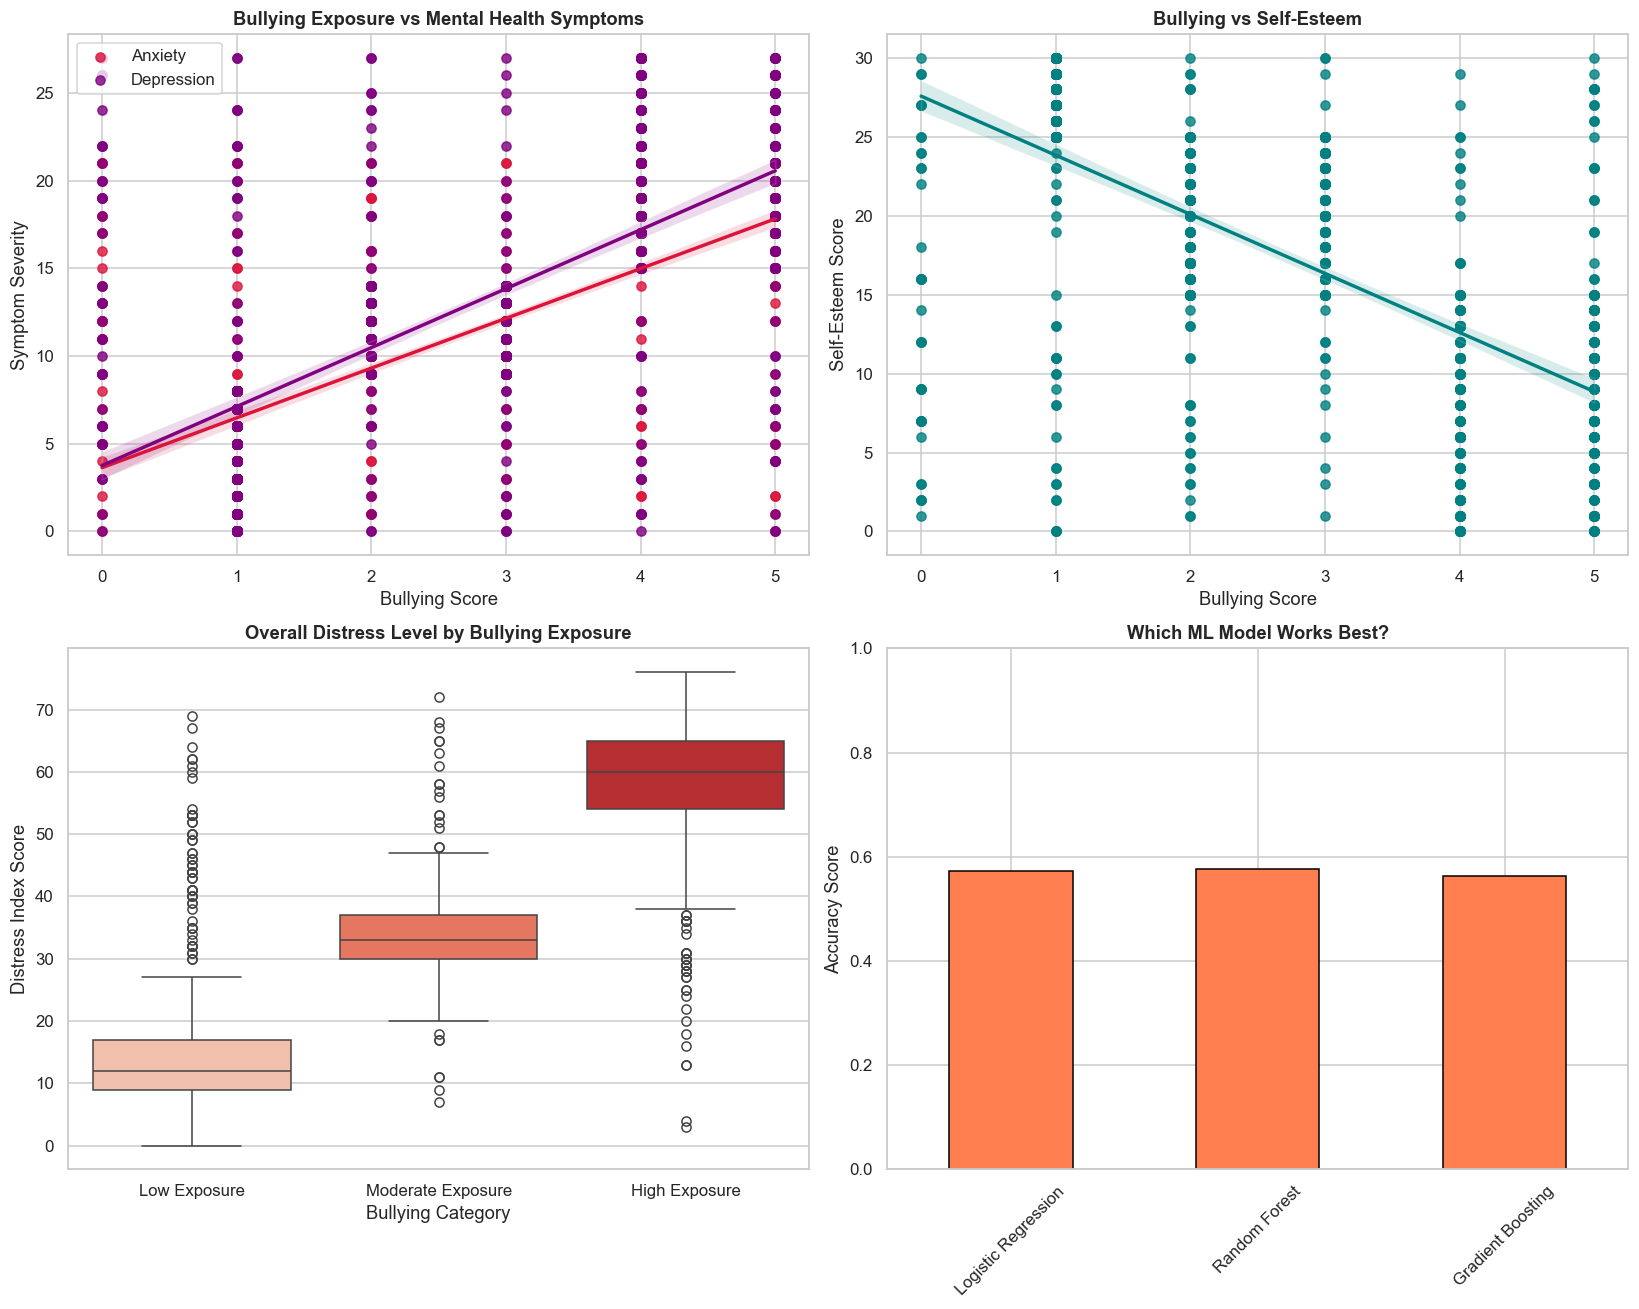


=== STAGE 7: CORRELATION HEATMAP ===
[OK] Correlation heatmap saved: correlation_heatmap.png


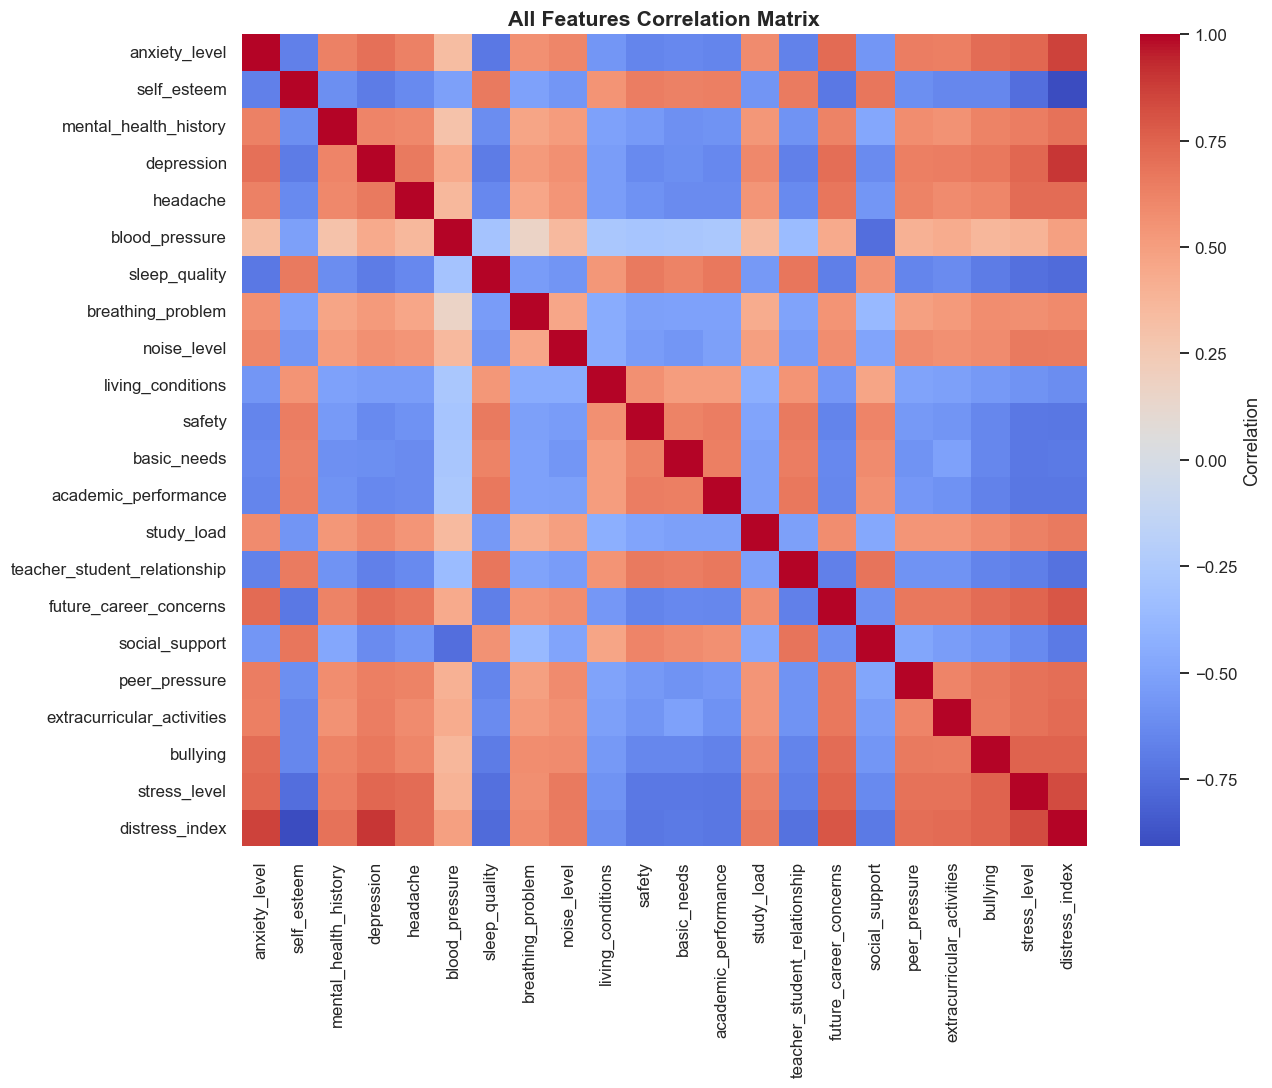


=== STAGE 8: SAVING RESULTS TO CSV ===
[OK] Summary statistics saved: processed_bullying_mental_health_summary.csv
[OK] ML model results saved: ML_Model_Results.csv

SUCCESS! Analysis complete and all files saved


In [117]:
if R3_DATA_PATH.exists():
    try:
        df_r3, model_results_r3 = run_pipeline_r3(R3_DATA_PATH, R3_OUTPUT_DIR)
    except Exception as e:
        print(f"[ERROR] Something went wrong: {e}")
else:
    print(f"[ERROR] File '{R3_DATA_PATH}' not found. Place it in the shared 'data' folder.")
